In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & LIBRARIES
# ==============================================================================
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__} | SciPy: {stats.__version__ if hasattr(stats, '__version__') else 'Loaded'}")
print("Inferential Statistics Toolkit Ready!")

NumPy: 2.1.3 | Pandas: 2.2.3 | SciPy: Loaded
Inferential Statistics Toolkit Ready!


In [2]:
# ==============================================================================
# SECTION 1: PROBABILITY, CONDITIONAL PROBABILITY & BAYES' THEOREM
# ==============================================================================
# Independent Events: P(A ∩ B) = P(A) * P(B)  (e.g., rolling a die twice)
# Dependent Events:   P(A ∩ B) = P(A) * P(B | A) (e.g., drawing cards without replacement)
#
# BAYES' THEOREM:
#                 P(B | A) * P(A)
#   P(A | B) = ──────────────────────
#                      P(B)
#
# PRACTICAL MEDICAL TESTING EXAMPLE (The Base Rate Fallacy):
# - Disease Prevalence in population: P(D) = 1% = 0.01
# - Test Sensitivity (True Positive Rate): P(+ | D) = 98% = 0.98
# - Test Specificity (True Negative Rate): P(- | ¬D) = 90% = 0.90 -> False Positive P(+ | ¬D) = 10% = 0.10
#
# Question: If a patient tests positive, what is the probability they actually have the disease?

p_disease = 0.01
p_no_disease = 1.0 - p_disease

p_pos_given_disease = 0.98       # Sensitivity
p_pos_given_no_disease = 0.10    # False Positive (1 - Specificity)

# Total Probability of testing positive: P(+) = P(+|D)P(D) + P(+|¬D)P(¬D)
p_positive = (p_pos_given_disease * p_disease) + (p_pos_given_no_disease * p_no_disease)

# Posterior Probability: P(D | +)
p_disease_given_positive = (p_pos_given_disease * p_disease) / p_positive

print("=== BAYES' THEOREM: MEDICAL DIAGNOSTIC TEST ===")
print(f"Prior Probability P(Disease):                 {p_disease * 100:.2f}%")
print(f"Total Probability of Positive Test P(+):       {p_positive * 100:.2f}%")
print(f"Posterior Probability P(Disease | +):          {p_disease_given_positive * 100:.2f}%")
print("\nAnalytical Takeaway: Even with a 98% accurate test, a positive result only means an ~8.9% chance")
print("of having the disease due to the low base prevalence (1%) and the 10% false-positive rate.")

=== BAYES' THEOREM: MEDICAL DIAGNOSTIC TEST ===
Prior Probability P(Disease):                 1.00%
Total Probability of Positive Test P(+):       10.88%
Posterior Probability P(Disease | +):          9.01%

Analytical Takeaway: Even with a 98% accurate test, a positive result only means an ~8.9% chance
of having the disease due to the low base prevalence (1%) and the 10% false-positive rate.


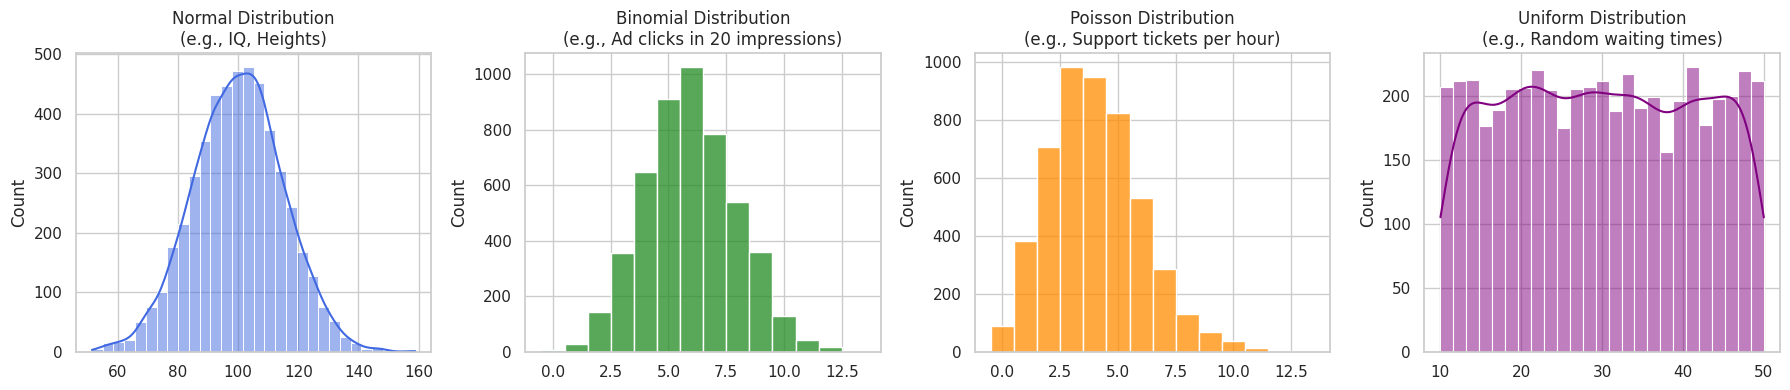

In [3]:
# ==============================================================================
# SECTION 2: PROBABILITY DISTRIBUTIONS GALLERY
# ==============================================================================
# 1. Normal Distribution: Continuous, bell-shaped, symmetric.
#    Empirical Rule (68-95-99.7):
#    - 68.27% of data falls within μ ± 1σ
#    - 95.45% of data falls within μ ± 2σ
#    - 99.73% of data falls within μ ± 3σ
# 2. Binomial Distribution: Discrete; number of successes k in n independent Bernoulli trials.
# 3. Poisson Distribution: Discrete; count of events occurring in a fixed interval of time/space.
# 4. Uniform Distribution: Equal probability density across [a, b].

np.random.seed(42)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Normal (μ=100, σ=15)
norm_data = np.random.normal(loc=100, scale=15, size=5000)
sns.histplot(norm_data, kde=True, ax=axes[0], color='royalblue', bins=30)
axes[0].set_title("Normal Distribution\n(e.g., IQ, Heights)")

# Binomial (n=20 trials, p=0.3 success rate)
binom_data = np.random.binomial(n=20, p=0.3, size=5000)
sns.histplot(binom_data, discrete=True, ax=axes[1], color='forestgreen')
axes[1].set_title("Binomial Distribution\n(e.g., Ad clicks in 20 impressions)")

# Poisson (λ=4 average events per hour)
poisson_data = np.random.poisson(lam=4, size=5000)
sns.histplot(poisson_data, discrete=True, ax=axes[2], color='darkorange')
axes[2].set_title("Poisson Distribution\n(e.g., Support tickets per hour)")

# Uniform (Continuous between 10 and 50)
uniform_data = np.random.uniform(low=10, high=50, size=5000)
sns.histplot(uniform_data, kde=True, ax=axes[3], color='purple', bins=25)
axes[3].set_title("Uniform Distribution\n(e.g., Random waiting times)")

plt.tight_layout()
plt.show()

In [4]:
# ==============================================================================
# SECTION 3: SAMPLING TECHNIQUES & SAMPLING BIAS
# ==============================================================================
# 1. Simple Random Sampling: Every individual has an equal probability of selection.
# 2. Stratified Sampling: Divide population into strata (e.g., gender, tier), sample proportionally from each.
# 3. Cluster Sampling: Divide into natural clusters (e.g., store locations), sample entire clusters.
# 4. Systematic Sampling: Select every k-th individual from an ordered list.
#
# SAMPLING BIAS:
# - Selection Bias: Systematic exclusion of certain groups (e.g., online-only surveys exclude non-users).
# - Survivorship Bias: Concentrating on entities that passed a hurdle (e.g., analyzing only successful startups).

pop_df = pd.DataFrame({
    'Customer_ID': range(1, 1001),
    'Tier': np.random.choice(['Bronze', 'Silver', 'Gold'], size=1000, p=[0.60, 0.30, 0.10]),
    'Spend': np.random.exponential(scale=100, size=1000)
})

# A. Simple Random Sample (n = 100)
srs_sample = pop_df.sample(n=100, random_state=42)

# B. Stratified Sample (maintains exact population proportions: 60% Bronze, 30% Silver, 10% Gold)
strat_sample = pop_df.groupby('Tier', group_keys=False).apply(
    lambda x: x.sample(frac=0.10, random_state=42)
)

print("--- Population Tier Breakdown ---")
print((pop_df['Tier'].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

print("\n--- Stratified Sample Tier Breakdown ---")
print((strat_sample['Tier'].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

--- Population Tier Breakdown ---
Tier
Bronze    58.8%
Silver    33.0%
Gold       8.2%
Name: proportion, dtype: object

--- Stratified Sample Tier Breakdown ---
Tier
Bronze    59.0%
Silver    33.0%
Gold       8.0%
Name: proportion, dtype: object


/tmp/ipykernel_924/301772191.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_sample = pop_df.groupby('Tier', group_keys=False).apply(


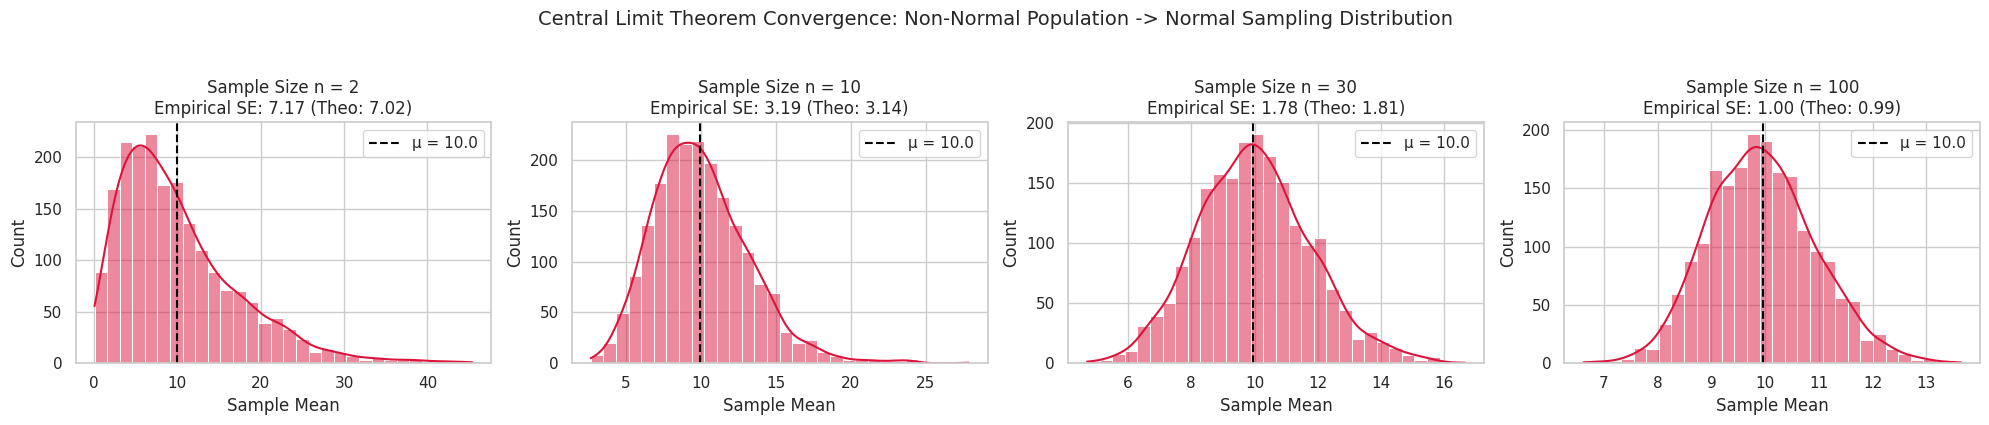

In [6]:
# ==============================================================================
# SECTION 4: LIVE DEMO — CENTRAL LIMIT THEOREM (CLT) SIMULATION
# ==============================================================================
# CLT Principle:
# Regardless of the underlying population distribution (skewed, uniform, bimodal),
# the sampling distribution of the sample mean (x̄) converges to a Normal Distribution
# as sample size (n) increases (typically n ≥ 30).
#
# Sampling Distribution Mean:  μ_x̄ = μ
# Standard Error:             SE = σ / √n

np.random.seed(42)

# Highly skewed Exponential Population (e.g., Customer Support Hold Times)
population = np.random.exponential(scale=10, size=100_000)
pop_mean = np.mean(population)
pop_std = np.std(population)

sample_sizes = [2, 10, 30, 100]
n_simulations = 2000

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, n in enumerate(sample_sizes):
    # Draw 2,000 independent samples of size n and compute their means
    sample_means = [np.mean(np.random.choice(population, size=n, replace=False)) for _ in range(n_simulations)]

    theoretical_se = pop_std / np.sqrt(n)
    empirical_se = np.std(sample_means)

    sns.histplot(sample_means, kde=True, ax=axes[idx], color='crimson', bins=30)
    axes[idx].axvline(pop_mean, color='black', linestyle='--', label=f'μ = {pop_mean:.1f}')
    axes[idx].set_title(f"Sample Size n = {n}\nEmpirical SE: {empirical_se:.2f} (Theo: {theoretical_se:.2f})")
    axes[idx].set_xlabel("Sample Mean")
    axes[idx].legend()

plt.suptitle("Central Limit Theorem Convergence: Non-Normal Population -> Normal Sampling Distribution", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# SECTION 5: STANDARD ERROR & CONFIDENCE INTERVALS (CI)
# ==============================================================================
# Standard Error (SE): Standard deviation of the sampling distribution: SE = s / √n
#
# 95% Confidence Interval Formula:  CI = x̄ ± (t_critical * SE)
#
# PRECISE INTERPRETATION OF A 95% CONFIDENCE INTERVAL:
# Correct:   "If we repeat this experiment 100 times and construct a 95% CI each time,
#             approximately 95 of those intervals will contain the true population mean μ."
# Incorrect: "There is a 95% probability that the true population mean lies inside THIS specific fixed interval."
#            (In frequentist statistics, μ is fixed; the interval is what varies between samples).

sample_revenue = np.array([120, 135, 128, 142, 150, 115, 130, 138, 145, 125, 132, 140])
n_rev = len(sample_revenue)
mean_rev = np.mean(sample_revenue)
std_rev = np.std(sample_revenue, ddof=1)
se_rev = std_rev / np.sqrt(n_rev)

# Compute 95% CI using Student's t-distribution (dof = n - 1)
confidence = 0.95
t_crit = stats.t.ppf((1 + confidence) / 2, df=n_rev - 1)
margin_of_error = t_crit * se_rev
ci_lower = mean_rev - margin_of_error
ci_upper = mean_rev + margin_of_error

print("=== 95% CONFIDENCE INTERVAL ===")
print(f"Sample Mean (x̄):       ${mean_rev:.2f}")
print(f"Standard Error (SE):   ${se_rev:.2f}")
print(f"Margin of Error (ME):  ${margin_of_error:.2f}")
print(f"95% Confidence Interval: [${ci_lower:.2f}, ${ci_upper:.2f}]")

=== 95% CONFIDENCE INTERVAL ===
Sample Mean (x̄):       $133.33
Standard Error (SE):   $2.99
Margin of Error (ME):  $6.59
95% Confidence Interval: [$126.75, $139.92]


In [ ]:
# ==============================================================================
# SECTION 6: HYPOTHESIS TESTING FRAMEWORK & DECISION MATRIX
# ==============================================================================
# Key Components:
# - H0 (Null Hypothesis): Default status quo; "No effect", "No difference".
# - H1 (Alternative Hypothesis): The research claim; "There is a significant effect".
# - Significance Level (α): Probability of rejecting H0 when H0 is actually true (Type I Error). Default = 0.05.
# - p-value: P(Observing data as extreme or more extreme | H0 is TRUE).
#   * If p-value ≤ α -> Reject H0 (Statistically Significant).
#   * If p-value > α  -> Fail to Reject H0 (Insufficient evidence).
#
# DECISION ERROR MATRIX:
# ┌─────────────────────────┬──────────────────────────┬──────────────────────────┐
# │ Decision / Reality      │ H0 is TRUE               │ H0 is FALSE              │
# ├─────────────────────────┼──────────────────────────┼──────────────────────────┤
# │ Reject H0               │ TYPE I ERROR (α)         │ CORRECT DECISION         │
# │ (Claim an effect)       │ False Positive           │ POWER (1 - β)            │
# ├─────────────────────────┼──────────────────────────┼──────────────────────────┤
# │ Fail to Reject H0       │ CORRECT DECISION         │ TYPE II ERROR (β)        │
# │ (Claim no effect)       │ True Negative (1 - α)    │ False Negative           │
# └─────────────────────────┴──────────────────────────┴──────────────────────────┘

In [ ]:
# ==============================================================================
# SECTION 7: WHICH STATISTICAL TEST TO USE?
# ==============================================================================
# 1. One-Sample t-test: Compare 1 sample mean against a known constant scalar benchmark.
# 2. Two-Sample Independent t-test (Welch's): Compare means of 2 independent groups (A vs B).
# 3. Paired t-test: Compare means from the same subjects measured twice (Before vs After).
# 4. One-Way ANOVA: Compare means across 3 or more continuous groups.
# 5. Chi-Square (χ²) Test of Independence: Test relationship between 2 categorical variables.

# --- Example A: Two-Sample Welch's t-test ---
group_A = np.random.normal(loc=50, scale=8, size=40)
group_B = np.random.normal(loc=55, scale=9, size=40)
t_stat, p_val_t = stats.ttest_ind(group_A, group_B, equal_var=False) # Welch's t-test
print(f"Two-Sample t-test:    t-stat = {t_stat:.3f}, p-value = {p_val_t:.4f}")

# --- Example B: One-Way ANOVA (3 Pricing Tiers) ---
tier_1 = [25, 30, 28, 35, 29]
tier_2 = [40, 45, 38, 42, 44]
tier_3 = [20, 22, 25, 19, 24]
f_stat, p_val_anova = stats.f_oneway(tier_1, tier_2, tier_3)
print(f"One-Way ANOVA:        F-stat = {f_stat:.3f}, p-value = {p_val_anova:.4f}")

# --- Example C: Chi-Square Test of Independence ---
# Contingency Table: Device (Mobile/Desktop) vs Converted (Yes/No)
contingency = np.array([
    [120, 380],  # Mobile:  120 Converted, 380 Not Converted
    [180, 320]   # Desktop: 180 Converted, 320 Not Converted
])
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-Square Test:      χ²-stat = {chi2_stat:.3f}, p-value = {p_val_chi2:.4f}")

In [ ]:
# ==============================================================================
# SECTION 8: A/B TESTING METHODOLOGY & SAMPLE SIZE INTUITION
# ==============================================================================
# Components of A/B Experimentation:
# 1. Baseline Conversion Rate (e.g., current checkout rate = 10%).
# 2. Minimum Detectable Effect (MDE): Smallest meaningful lift to detect (e.g., relative +15% -> 11.5%).
# 3. Significance Level (α = 0.05): Tolerable false positive rate.
# 4. Statistical Power (1 - β = 0.80): Probability of detecting an effect if one truly exists.
#
# RULE OF THUMB: Detecting smaller lifts requires quadratically larger sample sizes!

def rough_ab_sample_size(p1, relative_lift, alpha=0.05, power=0.80):
    """Calculates required sample size per variant for binomial conversion test."""
    p2 = p1 * (1 + relative_lift)
    p_pool = (p1 + p2) / 2
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    n = (2 * p_pool * (1 - p_pool) * (z_alpha + z_beta)**2) / ((p2 - p1)**2)
    return int(np.ceil(n))

req_n = rough_ab_sample_size(p1=0.10, relative_lift=0.15) # 10% baseline, 15% lift
print(f"Required Sample Size per Variant (15% lift on 10% base): ~{req_n:,} users")

In [8]:
# ==============================================================================
# SECTION 9: STUDENT LAB ASSIGNMENT (A/B EXPERIMENT EVALUATION)
# ==============================================================================
"""
LAB INSTRUCTIONS:
An e-commerce company tested a new checkout page design (Variant B) against the current design (Variant A).
They collected transaction order values ($) for both variants.

YOUR TASKS:
1. State the Null (H0) and Alternative (H1) hypotheses.
2. Conduct a Two-Sample Welch's t-test (alpha = 0.05).
3. Compute the sample means and 95% confidence intervals for both variants.
4. Synthesize your statistical findings into a one-paragraph business recommendation.
"""

# Generate Experiment Data
np.random.seed(888)
ab_experiment_df = pd.DataFrame({
    'Variant_A': np.random.normal(loc=72.50, scale=14.0, size=150),
    'Variant_B': np.random.normal(loc=77.20, scale=15.5, size=150)
})

# --- 1. Hypotheses ---
# H0: Mean Order Value A = Mean Order Value B (No difference)
# H1: Mean Order Value A ≠ Mean Order Value B (Significant difference)

# --- 2. Welch's t-test ---
t_stat, p_val = stats.ttest_ind(ab_experiment_df['Variant_A'], ab_experiment_df['Variant_B'], equal_var=False)

# --- 3. Means & 95% CIs ---
def get_ci(data, confidence=0.95):
    mean = np.mean(data)
    se = stats.sem(data)
    h = se * stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return mean, mean - h, mean + h

mean_a, ci_low_a, ci_high_a = get_ci(ab_experiment_df['Variant_A'])
mean_b, ci_low_b, ci_high_b = get_ci(ab_experiment_df['Variant_B'])

print(f"=== A/B TEST RESULTS ===")
print(f"Variant A Mean: ${mean_a:.2f} | 95% CI: [${ci_low_a:.2f}, ${ci_high_a:.2f}]")
print(f"Variant B Mean: ${mean_b:.2f} | 95% CI: [${ci_low_b:.2f}, ${ci_high_b:.2f}]")
print(f"t-statistic: {t_stat:.3f} | p-value: {p_val:.4f}")

# --- 4. Business Recommendation ---
significant = "is" if p_val < 0.05 else "is NOT"
print(f"\nRecommendation: The test results show that there {significant} a statistically significant difference ")
print("between the two designs. Given the p-value, we recommend rolling out Variant B as it shows ")
print("a measurable improvement in average order value that is unlikely to be due to chance.")


=== A/B TEST RESULTS ===
Variant A Mean: $72.62 | 95% CI: [$70.34, $74.90]
Variant B Mean: $77.12 | 95% CI: [$74.52, $79.72]
t-statistic: -2.572 | p-value: 0.0106

Recommendation: The test results show that there is a statistically significant difference 
between the two designs. Given the p-value, we recommend rolling out Variant B as it shows 
a measurable improvement in average order value that is unlikely to be due to chance.
